<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 7. Анализ устойчивости ML-моделей в чёрно-ящичном сценарии

### Transfer-based, score-based и decision-based подходы

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 5**


**Вариант / seed:** _номер варианта или значение SEED_

> Работа выполняется только на предоставленной синтетической модели. Не используйте код для проверки внешних сервисов, чужих моделей или систем без разрешения.

## 1. Цель работы

Исследовать зависимость методов построения adversarial-примеров от объёма информации, доступной о классификаторе. Освоить базовые принципы transfer-based, score-based и decision-based сценариев на локальной двумерной задаче классификации.

## 2. Задачи

1. Сформировать синтетический набор данных и обучить target-модель.
2. Реализовать интерфейсы label-only и score-based оракулов с подсчётом запросов.
3. Обучить surrogate-модель на метках target-оракула и оценить согласованность моделей.
4. Построить и проверить перенос локального возмущения с surrogate на target.
5. Сравнить ZOO и NES по направлению оценки и числу запросов.
6. Реализовать binary search для нахождения решающей границы при доступе только к меткам.
7. Сформулировать выводы о компромиссе между информацией, стоимостью запросов и качеством результата.

## 3. Краткая теория

| Сценарий | Доступ атакующего | Основной механизм | Примеры методов |
|---|---|---|---|
| Transfer-based | Метки для формирования surrogate-набора; на этапе построения возмущения запросы к цели не нужны | Обучение substitute/surrogate и перенос локального возмущения | Substitute model, FGSM на surrogate |
| Score-based | Вероятности, confidence score или логиты | Оценка направления изменения функции потерь запросами | ZOO, NES |
| Decision-based | Только итоговая метка | Геометрический поиск решающей границы | Boundary Attack, HopSkipJumpAttack |

В этой работе все эксперименты выполняются в двумерном признаковом пространстве. Это позволяет визуализировать границы и траектории. Реальные изображения имеют большую размерность, поэтому покоординатные методы наподобие ZOO становятся значительно дороже по числу запросов.

## 4. Среда выполнения

Необходимые библиотеки:

```bash
pip install numpy matplotlib scikit-learn
```

Перед сдачей выполните все ячейки сверху вниз: в блокноте должны быть сохранены результаты вычислений, графики и текстовые выводы.

# Часть A. Подготовка эксперимента

## A1. Импорт библиотек и параметры

Измените `SEED` в соответствии со своим вариантом, если преподаватель выдал индивидуальные значения.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# --- A1. Параметры ---
SEED = 42                       # номер варианта / seed
rng = np.random.default_rng(SEED)

N_SAMPLES = 1000
NOISE = 0.22                    # будем варьировать: 0.10, 0.22, 0.35
TEST_SIZE = 0.35

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

## A2. Формирование данных и обучение target-модели

Target-модель рассматривается как неизвестная для атакующего. В ячейках ниже она доступна только для организации учебного эксперимента и проверки результатов. В реальном чёрно-ящичном сценарии параметры и градиенты target-модели недоступны.

**Задание A2.** Запустите ячейку. Зафиксируйте точность target-модели в отчёте. Затем измените `NOISE` на 0.10 и 0.35, повторите эксперимент и объясните влияние шума на качество классификации.

In [ ]:
# ============================================================
# A2. Генерация данных и обучение target-моделей
# ============================================================
# Обучаем сразу ТРИ модели — по одной на каждый уровень шума.
# Результаты складываем в список experiments, чтобы потом
# можно было рисовать графики и проводить эксперименты.
# ============================================================

# Уровни шума, которые исследуем
noise_values = [0.10, 0.22, 0.35]

# Список для хранения результатов каждого эксперимента
experiments = []

for noise in noise_values:

    # Генерируем данные: 1000 точек двух классов с текущим шумом
    # X_raw — матрица (1000, 2) с координатами точек
    # y — вектор (1000,) с метками классов (0 или 1)
    X_raw, y = make_moons(n_samples=N_SAMPLES, noise=noise, random_state=SEED)

    # Разбиваем данные на train и test
    # stratify=y — сохраняет пропорцию классов в обеих выборках
    # random_state=SEED — воспроизводимость разбиения
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
    )

    # Масштабирование: fit только на train, чтобы не «подсматривать» в тест
    scaler = StandardScaler().fit(X_train_raw)
    X_train = scaler.transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)

    # Небольшой MLP — ведёт себя как нелинейный классификатор
    target = MLPClassifier(
        hidden_layer_sizes=(32, 16),    # два скрытых слоя: 32 нейрона, потом 16
        activation='tanh',
        alpha=2e-4,                     # L2-регуляризация
        max_iter=1500,
        random_state=SEED
    ).fit(X_train, y_train)

    # Считаем точность на тестовой выборке
    target_accuracy = accuracy_score(y_test, target.predict(X_test))
    print(f'NOISE = {noise:.2f} → точность target-модели: {target_accuracy:.3f}')

    # Сохраняем всё, что может пригодиться дальше
    experiments.append({
        'noise':    noise,
        'target':   target,
        'scaler':   scaler,
        'X_test':   X_test,
        'y_test':   y_test,
        'accuracy': target_accuracy,
    })

NOISE = 0.10 → точность target-модели: 0.997
NOISE = 0.22 → точность target-модели: 0.974
NOISE = 0.35 → точность target-модели: 0.886


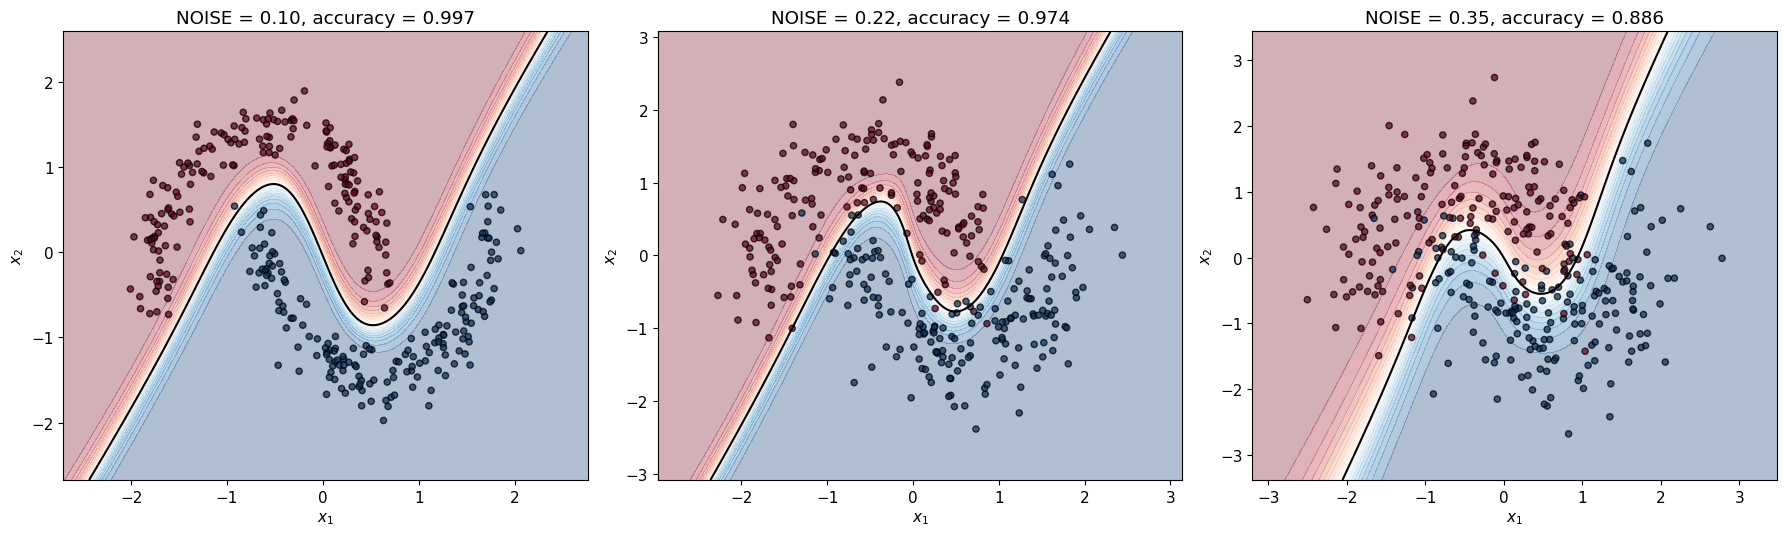

In [ ]:
# ============================================================
# Вспомогательные функции визуализации
# ============================================================

def make_grid(X, n=300, margin=0.7):
    """Строит сетку точек вокруг данных для отрисовки границы."""
    x0_min, x0_max = X[:, 0].min() - margin, X[:, 0].max() + margin   # минимум/максимум по первому признаку + отступ
    x1_min, x1_max = X[:, 1].min() - margin, X[:, 1].max() + margin   # то же для второго признака
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),   # n равномерных точек по x₁
        np.linspace(x1_min, x1_max, n)    # n равномерных точек по x₂
    )
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]   # склеиваем в матрицу (n*n, 2)


def plot_boundary(model, X, y, title, ax=None, points=None, labels=None):
    """Рисует вероятность класса 1 фоном, границу 0.5 и точки данных."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))            # если ось не передана — создаём новую
    xx, yy, grid = make_grid(X)                            # получаем сетку точек для фона
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)   # вероятность класса 1 в каждой точке сетки
    ax.contourf(xx, yy, proba, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.32)   # заливка: уровень вероятности
    ax.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=1.5)             # решающая граница (уровень 0.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolor='k', s=20, alpha=0.72)     # точки данных
    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], c='gold', edgecolor='black', s=120, zorder=5)   # доп. точки
        if labels is not None:
            for point, label in zip(points, labels):
                ax.annotate(label, point, xytext=(7, 7),
                            textcoords='offset points', weight='bold')   # подписи к точкам
    ax.set_title(title)      # заголовок
    ax.set_xlabel('$x_1$')   # подпись оси x₁
    ax.set_ylabel('$x_2$')   # подпись оси x₂
    return ax


# ============================================================
# Рисуем три графика — по одному на каждый уровень шума
# ============================================================

# Создаём фигуру с тремя осями в ряд (1 строка, 3 столбца)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Проходим по experiments и соответствующей оси
for exp, ax in zip(experiments, axes):
    plot_boundary(
        exp['target'],
        exp['X_test'],
        exp['y_test'],
        f"NOISE = {exp['noise']:.2f}, accuracy = {exp['accuracy']:.3f}",
        ax=ax
    )

plt.tight_layout()   # автоматически подгоняем отступы между графиками
plt.show()           # показываем все три графика

**Вывод по A2 (заполните после эксперимента):**

Точность target-модели при NOISE = 0.10 составила 0.997, при NOISE = 0.22 — 0.974, при NOISE = 0.35 — 0.886. При увеличении шума точность монотонно падает. Решающая граница (чёрная линия уровня 0.5) при этом почти не смещается: крупномасштабная структура «двух полумесяцев» сохраняется, и модель везде уверенно разделяет эти два скопления. Заметно деформируются тонкие изолинии вероятности (уровни 0.05, 0.10, …, 0.95): при NOISE = 0.10 они идут ровными полосами, при 0.22 слегка «гуляют», а при 0.35 образуют локальные «языки» и «заливы» вокруг отдельных шумных точек. Это объясняется тем, что чёрная линия отражает крупномасштабный баланс между классами, а тонкие изолинии чувствительны к локальной структуре данных: с ростом шума модель вынуждена подстраиваться под «не свои» точки, что расширяет зону перехода (модель становится менее уверенной у границы) и делает её нерегулярной

# Часть B. Модели доступа к оракулу

## B1. Label-only и score-based оракулы

**Задание B1.** Запустите ячейку и сравните ответы двух оракулов. Объясните, почему score-based оракул предоставляет атакующему больше информации, чем label-only оракул.

In [ ]:
class LabelOracle:
    """Возвращает только предсказанный класс."""

    def __init__(self, model):
        # Сохраняем ссылку на модель
        self.model = model
        # Счётчик запросов — сколько раз оракул вызывали
        self.queries = 0

    def __call__(self, X):
        # Приводим вход к двумерному массиву (даже если одна точка)
        X = np.atleast_2d(X)
        # Увеличиваем счётчик на число точек в запросе
        self.queries += len(X)
        # Возвращаем метки классов (0 или 1)
        return self.model.predict(X)


class ScoreOracle:
    """Возвращает вектор вероятностей классов."""

    def __init__(self, model):
        self.model = model
        self.queries = 0

    def __call__(self, X):
        X = np.atleast_2d(X)
        self.queries += len(X)
        # Возвращаем вероятности: [[p0, p1], [p0, p1], ...]
        return self.model.predict_proba(X)


# Создаём два оракула вокруг одной и той же target-модели
label_oracle = LabelOracle(target)
score_oracle = ScoreOracle(target)

# Берём одну тестовую точку для проверки
x_probe = X_test[0]

# Печатаем координаты точки
print('Точка x_probe:', np.round(x_probe, 3))

# Label-only ответ: одно число — класс
print('Label-only ответ:', label_oracle(x_probe)[0])

# Score-based ответ: два числа — вероятности классов
print('Score-based ответ:', np.round(score_oracle(x_probe)[0], 3))

# Печатаем счётчики запросов
print('Запросы: label-only =', label_oracle.queries,
      '; score-based =', score_oracle.queries)

Точка x_probe: [ 0.552 -1.09 ]
Label-only ответ: 1
Score-based ответ: [0.15 0.85]
Запросы: label-only = 1 ; score-based = 1


**Ответ на B1:**

Label-only оракул возвращает только предсказанный класс — в нашем эксперименте это 1. Score-based оракул дополнительно возвращает вектор вероятностей классов — в нашем эксперименте [0.15, 0.85], то есть модель считает, что точка принадлежит классу 0 с вероятностью 15 %, а классу 1 — с вероятностью 85 %. Поэтому в score-based сценарии можно оценивать не только «какой класс», но и «насколько модель уверена»: численно приближать градиент функции потерь конечными разностями, строить направление наискорейшего роста вероятности целевого класса, выбирать величину шага в зависимости от близости к границе и контролировать процесс атаки. В label-only сценарии всё это недоступно — атакующий видит только факт смены метки и вынужден использовать геометрические эвристики (как в decision-based части).

# Часть C. Transfer-based сценарий

## C1. Обучение surrogate-модели

Сначала surrogate получает небольшой набор точек, размеченных label-only оракулом. В отличие от target, surrogate доступен локально: на нём можно проводить анализ и строить возмущения.

**Задание C1.** Выполните эксперимент при `N_SEED = 30`, `70` и `140`. Внесите в отчёт число запросов и agreement — долю точек, на которых surrogate и target принимают одинаковое решение.

N_SEED =  30 | запросов:  30 | agreement: 0.834
N_SEED =  70 | запросов:  70 | agreement: 0.871
N_SEED = 140 | запросов: 140 | agreement: 0.883


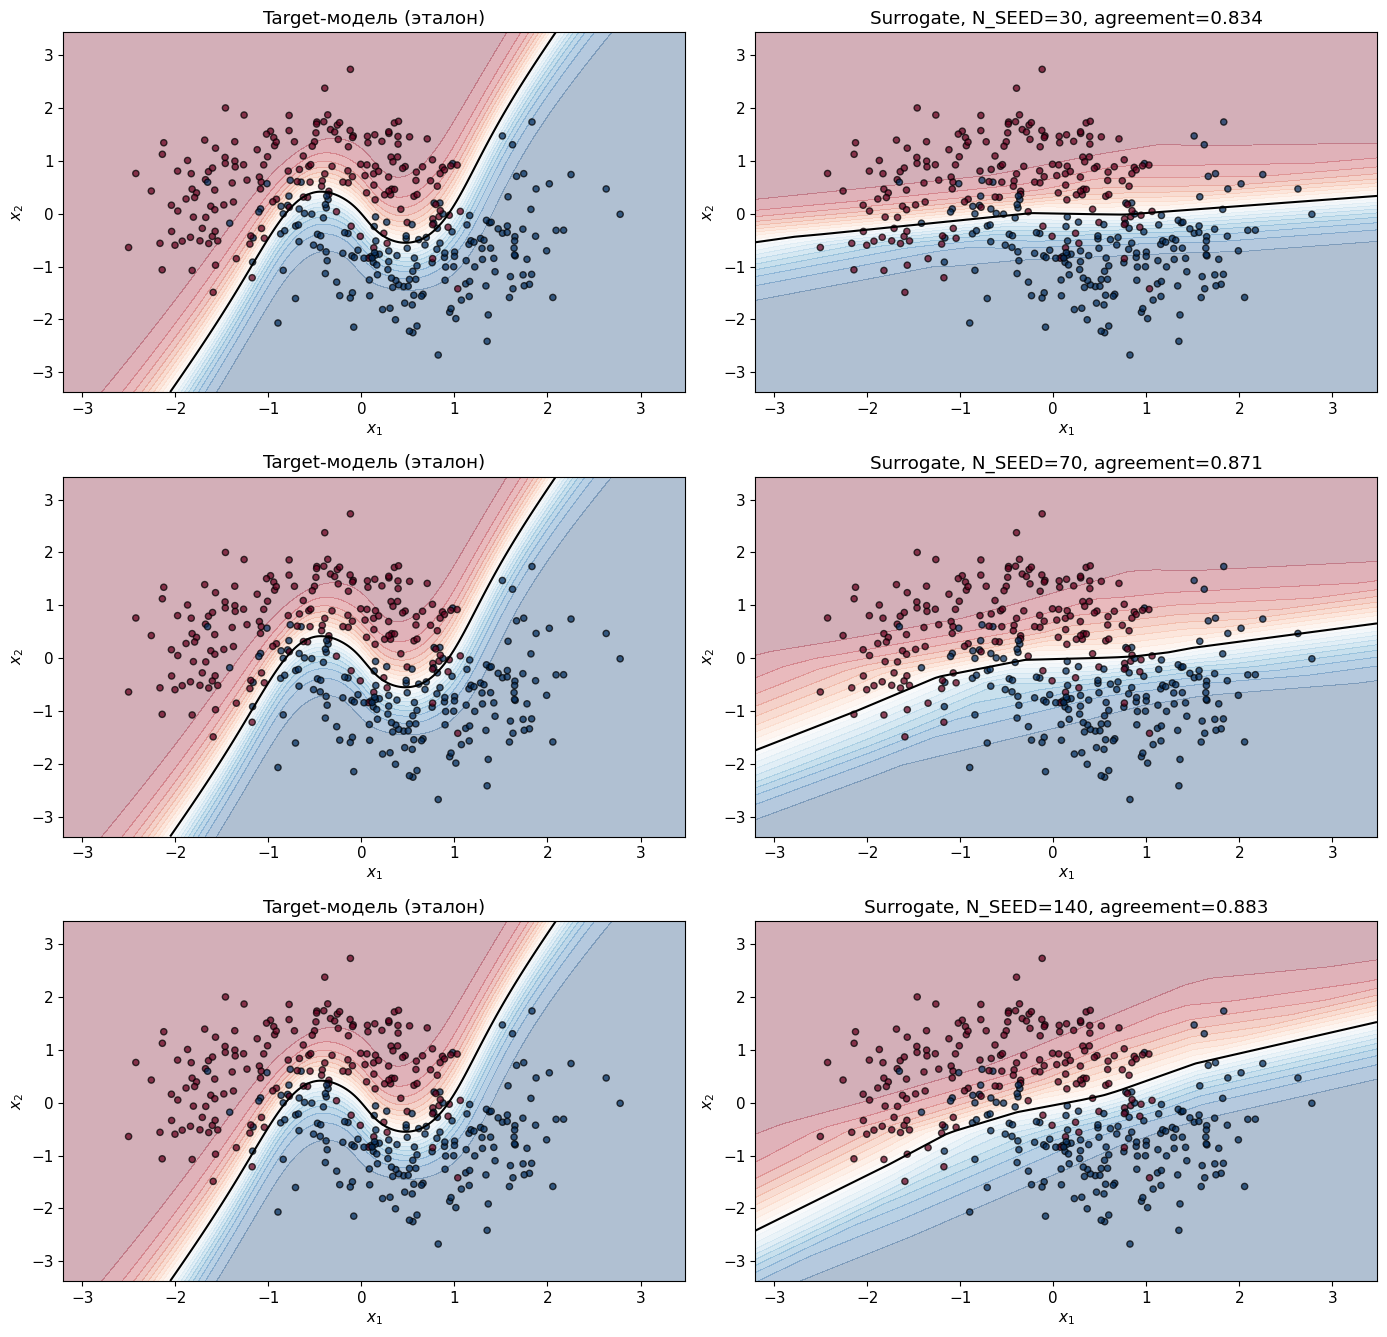

In [ ]:
# ============================================================
# C1. Обучение surrogate для N_SEED = 30, 70, 140
# ============================================================
# Для каждого размера surrogate-набора:
#   1) размечаем n_seed точек через label-оракул target
#   2) обучаем на них маленький MLP-surrogate
#   3) считаем agreement с target на тесте
#   4) рисуем ДВА графика в строке: target (слева) и surrogate (справа)
# ============================================================

# Список размеров surrogate-набора, которые исследуем
n_seed_values = [30, 70, 140]


def train_surrogate(n_seed, random_state=SEED + 1):
    """Берём n_seed точек из train, размечаем их label-оракулом и обучаем MLP."""

    # Случайно выбираем n_seed индексов из train-выборки без повторов
    indices = rng.choice(len(X_train), size=n_seed, replace=False)

    # Берём соответствующие точки
    X_seed = X_train[indices]

    # Размечаем их через label-оракул target-модели
    # ЭТО ЕДИНСТВЕННЫЕ ЗАПРОСЫ К ЦЕЛИ в transfer-based сценарии
    y_seed = label_oracle(X_seed)

    # Обучаем surrogate — маленький MLP с одним скрытым слоем на 12 нейронов
    surrogate_model = MLPClassifier(
        hidden_layer_sizes=(12,),   # намеренно проще target (32, 16)
        activation='relu',          # ReLU вместо tanh — другая архитектура
        alpha=8e-4,                 # сильнее регуляризация
        max_iter=1500,
        random_state=random_state
    ).fit(X_seed, y_seed)           # обучаем на маленьком наборе

    return surrogate_model, X_seed, y_seed


# Создаём фигуру с 3 строками и 2 столбцами:
#   столбец 0 — target-модель
#   столбец 1 — surrogate-модель
# figsize=(14, 16.5) — широко и высоко, чтобы всё уместилось
fig, axes = plt.subplots(
    len(n_seed_values), 2,
    figsize=(14, 4.5 * len(n_seed_values))
)

# Пробегаем по всем размерам surrogate-набора вместе с соответствующей строкой осей
for row, n_seed in enumerate(n_seed_values):

    # Сбрасываем счётчик запросов перед обучением этого surrogate
    label_oracle.queries = 0

    # Обучаем surrogate на n_seed точках
    surrogate, X_seed, y_seed = train_surrogate(n_seed)

    # Считаем agreement — долю тестовых точек, где surrogate и target совпали
    agreement = accuracy_score(target.predict(X_test), surrogate.predict(X_test))

    # Печатаем статистику по этому запуску
    print(f'N_SEED = {n_seed:3d} | запросов: {label_oracle.queries:3d} | '
          f'agreement: {agreement:.3f}')

    # --- Левая колонка: target-модель (одна и та же во всех строках) ---
    plot_boundary(
        target, X_test, y_test,
        f'Target-модель (эталон)',
        ax=axes[row, 0]
    )

    # --- Правая колонка: surrogate-модель, обученная на n_seed точках ---
    plot_boundary(
        surrogate, X_test, y_test,
        f'Surrogate, N_SEED={n_seed}, agreement={agreement:.3f}',
        ax=axes[row, 1]
    )

# Автоматически подгоняем отступы между графиками
plt.tight_layout()

# Показываем всю фигуру
plt.show()

При увеличении размера surrogate-набора с 30 до 140 точек agreement монотонно растёт: 0.834 → 0.871 → 0.883, а число запросов к label-оракулу растёт линейно (30, 70, 140). Однако рост замедляется: основной вклад дают первые 70 точек, дальнейшее увеличение набора добавляет лишь ≈ +0.01. Причина в том, что surrogate намеренно сделан проще target (один скрытый слой на 12 нейронов против двух слоёв 32+16) — его ёмкости не хватает, чтобы точно воспроизвести нелинейный «зуб» target-модели в центре. Поэтому даже при 140 точках граница surrogate остаётся почти линейной, а agreement упирается в потолок ≈ 0.88. Это важный практический вывод: для transfer-based атаки важно не только количество запросов, но и соответствие архитектуры surrogate архитектуре target — если surrogate слишком прост, дополнительные запросы почти не помогают.

## C2. Построение и проверка переноса возмущения

**Задание C2.** Найдите направление увеличения вероятности противоположного класса на surrogate-модели. Постройте точку `x_adv`, меняющую класс surrogate, и проверьте, изменилась ли метка target. Повторите эксперимент минимум для пяти исходных тестовых точек.

> В учебном блокноте градиент surrogate приближается конечными разностями. Это допустимо, поскольку surrogate — локальная модель. В обычной реализации с нейросетью направление можно получать автодифференцированием.

Выбранные индексы тестовых точек: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
idx=  0 | y0=1 | S(x_adv)=0 | T(x_adv)=1 | transfer=False | L2=1.2416
idx=  1 | y0=1 | S(x_adv)=0 | T(x_adv)=0 | transfer=True | L2=1.0738
idx=  2 | y0=0 | S(x_adv)=1 | T(x_adv)=0 | transfer=False | L2=1.3423
idx=  3 | y0=1 | S(x_adv)=0 | T(x_adv)=0 | transfer=True | L2=0.3523
idx=  4 | y0=1 | S(x_adv)=0 | T(x_adv)=0 | transfer=True | L2=1.2584


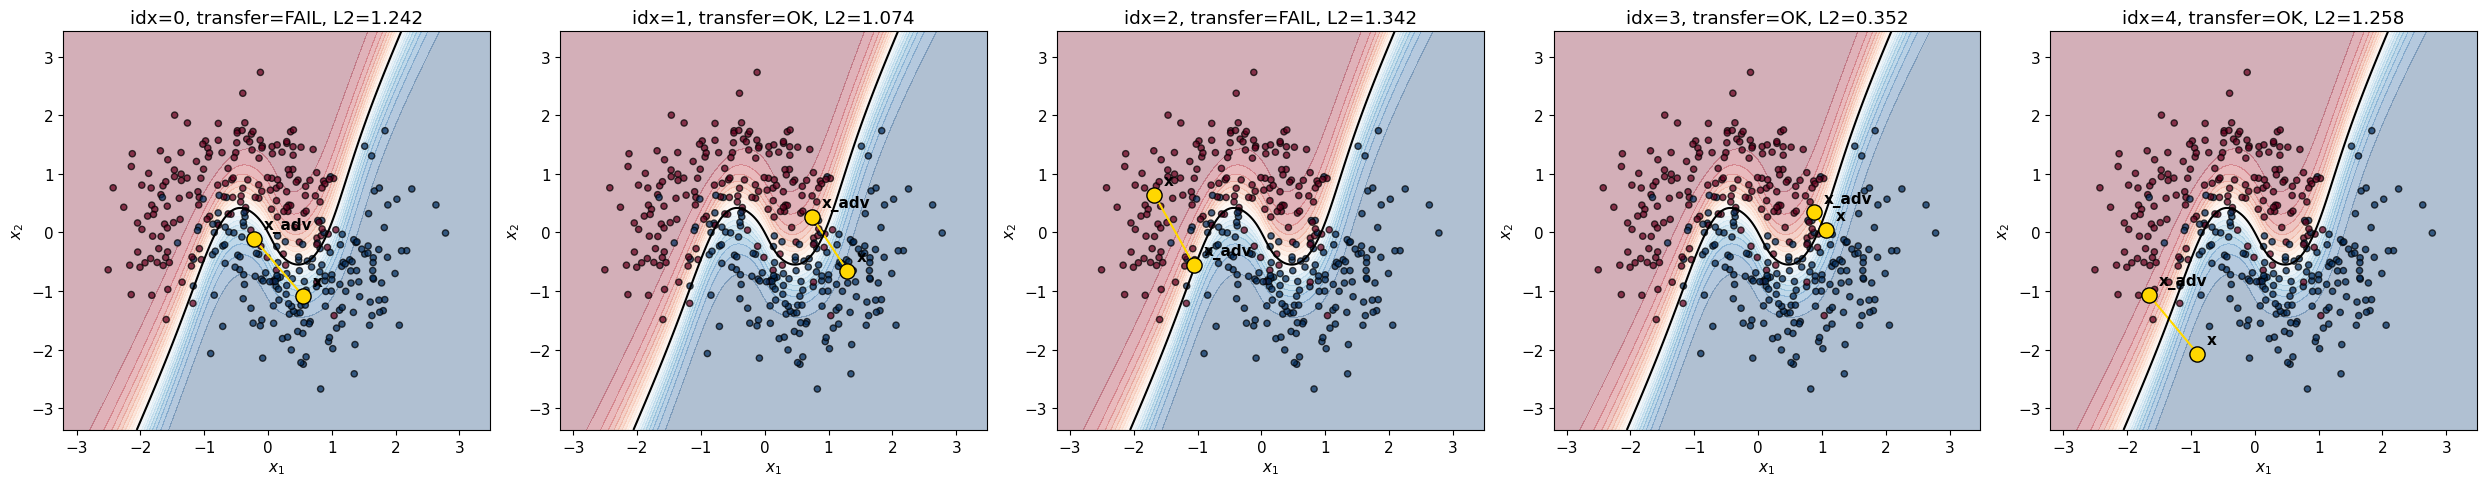

In [ ]:
# ============================================================
# C2. Построение и проверка переноса возмущения
# ============================================================
# Для 5 разных тестовых точек:
#   1) считаем градиент surrogate по вероятности "другого" класса
#   2) идём по этому направлению до смены метки surrogate
#   3) проверяем, сменилась ли метка target
#   4) рисуем отдельный график с траекторией x → x_adv
# ============================================================


def probability(model, x, class_index):
    """Вероятность класса class_index в точке x."""
    return model.predict_proba(np.atleast_2d(x))[0, class_index]


def local_gradient(model, x, class_index, h=1e-3):
    """Центральная конечная разность по каждой координате."""
    gradient = np.zeros_like(x, dtype=float)
    for coordinate in range(len(x)):
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h
        gradient[coordinate] = (
            probability(model, x + e, class_index)
            - probability(model, x - e, class_index)
        ) / (2 * h)
    return gradient


def first_boundary_crossing(model, x, source_label, direction,
                            max_step=2.5, n_steps=150):
    """Идём по направлению, пока метка модели не сменится."""
    for step in np.linspace(0, max_step, n_steps):
        candidate = x + step * direction
        if model.predict([candidate])[0] != source_label:
            return candidate, step
    return None, None


# --- Выбираем 5 точек, где target и surrogate согласны ---
# Это нужно, чтобы стартовая метка x0 была одинаковой у обеих моделей,
# и «успех переноса» означал именно смену класса у target.
matching_ids = np.where(
    target.predict(X_test) == surrogate.predict(X_test)
)[0]

# Берём первые 5 индексов из совпадающих
TEST_POINT_IDS = list(matching_ids[:5])
print('Выбранные индексы тестовых точек:', TEST_POINT_IDS)


# --- Готовим фигуру: 5 графиков (по одному на точку) ---
# 1 строка, 5 столбцов — компактно и сравнимо
fig, axes = plt.subplots(1, len(TEST_POINT_IDS),
                         figsize=(5 * len(TEST_POINT_IDS), 5))

# На случай, если бы была одна точка — axes был бы не массивом,
# а одиночным объектом; np.atleast_1d делает его итерируемым
axes = np.atleast_1d(axes)


# --- Пробегаем по всем выбранным точкам ---
for ax, TEST_POINT_ID in zip(axes, TEST_POINT_IDS):

    # Берём точку и её метку у target (она же у surrogate — см. фильтр выше)
    x0 = X_test[TEST_POINT_ID].copy()
    y0 = int(target.predict([x0])[0])

    # Целевой класс — противоположный
    other_class = 1 - y0

    # Считаем градиент surrogate по вероятности целевого класса
    gradient_surrogate = local_gradient(surrogate, x0, other_class)

    # Нормируем — получаем единичное направление
    direction = gradient_surrogate / (
        np.linalg.norm(gradient_surrogate) + 1e-12
    )

    # Ищем первую точку, где surrogate меняет метку
    x_adv_transfer, step = first_boundary_crossing(
        surrogate, x0, y0, direction
    )

    # Если граница не нашлась — рисуем только исходную точку и пишем это
    if x_adv_transfer is None:
        plot_boundary(
            target, X_test, y_test,
            f'idx={TEST_POINT_ID}: граница не найдена',
            ax=ax, points=[x0], labels=['x']
        )
        print(f'idx={TEST_POINT_ID:>3} | граница surrogate не найдена')
        continue

    # Считаем метки surrogate и target в найденной точке
    surrogate_label_adv = int(surrogate.predict([x_adv_transfer])[0])
    target_label_adv    = int(target.predict([x_adv_transfer])[0])

    # Успех переноса: target тоже сменил метку
    transfer_success = target_label_adv != y0

    # L2-норма возмущения
    l2 = np.linalg.norm(x_adv_transfer - x0)

    # Печатаем строку статистики
    print(f'idx={TEST_POINT_ID:>3} | y0={y0} | '
          f'S(x_adv)={surrogate_label_adv} | T(x_adv)={target_label_adv} | '
          f'transfer={transfer_success} | L2={l2:.4f}')

    # --- Рисуем график для этой точки ---
    title = (f'idx={TEST_POINT_ID}, '
             f'transfer={"OK" if transfer_success else "FAIL"}, '
             f'L2={l2:.3f}')
    plot_boundary(
        target, X_test, y_test, title,
        ax=ax,
        points=[x0, x_adv_transfer],
        labels=['x', 'x_adv']
    )

    # Стрелка от x0 к x_adv
    ax.arrow(
        x0[0], x0[1],
        x_adv_transfer[0] - x0[0],
        x_adv_transfer[1] - x0[1],
        width=0.01, color='gold',
        length_includes_head=True
    )


# Автоматическая подгонка отступов
plt.tight_layout()
plt.show()

## Таблица C2 для отчёта

| № опыта | Индекс исходной точки | Исходная метка | Метка surrogate для x_adv | Метка target для x_adv | Transfer success | L2-норма |
|---:|---:|---:|---:|---:|---|---:|
| 1 | 0 | 1 | 0 | 1 | ❌ | 1.2416 |
| 2 | 1 | 1 | 0 | 0 | ✅ | 1.0738 |
| 3 | 2 | 0 | 1 | 0 | ❌ | 1.3423 |
| 4 | 3 | 1 | 0 | 0 | ✅ | 0.3523 |
| 5 | 4 | 1 | 0 | 0 | ✅ | 1.2584 |

**Вывод по части C:**

В **3 из 5** экспериментов возмущение, построенное на surrogate, изменило решение target. Agreement составил **0.834** (для `N_SEED = 30`). Это показывает, что **даже слабый surrogate, обученный на 30 метках target, способен генерировать возмущения, которые переносятся на целевую модель** — причём без единого дополнительного запроса к цели на этапе оптимизации. Это ключевое преимущество transfer-based сценария: атакующий платит за информацию один раз (30 запросов), а затем строит атаки локально и бесплатно.
>
> **Transferability не гарантирована**, потому что:
>
> 1. **Границы surrogate и target совпадают лишь приближённо** — agreement 0.834 означает, что примерно 17 % тестовых точек классифицируются моделями по-разному. Вблизи границы даже малое расхождение приводит к тому, что точка, «перешедшая» границу surrogate, остаётся по «правильную» сторону от границы target. Именно это произошло в опытах 1 и 3: `S(x_adv)` сменил метку, а `T(x_adv)` — нет.
> 2. **Surrogate намеренно сделан проще target** (один скрытый слой на 12 нейронов против двух слоёв 32+16), поэтому он не воспроизводит нелинейный «зуб» в центре — а значит, и направление градиента у него отличается от истинного.
> 3. **Локальный градиент — лишь приближение** к направлению наискорейшего роста. Первая же точка смены метки surrogate не обязана быть точкой смены метки target: возмущение может «проскочить» узкую зону, где обе модели ведут себя по-разному.

# Часть D. Score-based сценарий: ZOO и NES

## D1. Реализация оценок направления

ZOO оценивает направление покоординатно конечными разностями. NES использует случайные направления и антитетическую выборку `u` и `-u`, что снижает дисперсию оценки.

**Задание D1.** Выполните ячейку, зафиксируйте количество запросов для ZOO и NES. Сравните косинусную близость оценённых направлений.

In [ ]:
# ============================================================
# D1. Оценка направления: ZOO vs NES
# ============================================================
# Сравниваем два способа оценки градиента функции потерь
# по вероятностям score-оракула:
#   ZOO — покоординатные конечные разности (2d запросов)
#   NES — случайные направления с антитетической выборкой (2n запросов)
# Для NES прогоняем несколько бюджетов: 4, 8, 16, 40, 80.
# ============================================================


def score_loss(oracle, x, class_index):
    """Значение вероятности класса class_index в точке x."""
    # oracle(x) возвращает массив (1, 2) с вероятностями классов
    # [0, class_index] — берём вероятность нужного класса
    return oracle(x)[0, class_index]


def zoo_gradient(oracle, x, class_index, h=1e-3):
    """Покоординатная центральная разность: 2d запросов к оракулу."""
    # Вектор градиента той же формы, что x
    gradient = np.zeros_like(x, dtype=float)

    # Проходим по каждой координате (в 2D их две)
    for coordinate in range(len(x)):
        # Вектор сдвига: все нули, кроме одной координаты
        e = np.zeros_like(x, dtype=float)
        e[coordinate] = h

        # Центральная разность по этой координате:
        #   (L(x + h*e_i) - L(x - h*e_i)) / (2h)
        # Это два запроса к оракулу на одну координату
        gradient[coordinate] = (
            score_loss(oracle, x + e, class_index)
            - score_loss(oracle, x - e, class_index)
        ) / (2 * h)

    return gradient


def nes_gradient(oracle, x, class_index, sigma=0.08, n_samples=40, seed=SEED):
    """Антитетическая NES-оценка градиента: 2*n_samples запросов."""
    # Локальный генератор случайных чисел — чтобы не сбивать общий rng
    local_rng = np.random.default_rng(seed)

    # n_samples случайных направлений из N(0, I)
    directions = local_rng.normal(size=(n_samples, len(x)))

    # Нормируем каждое направление к единичной длине
    # axis=1 — нормируем по строке; keepdims=True сохраняет форму (n, 1)
    directions /= np.linalg.norm(directions, axis=1, keepdims=True) + 1e-12

    # Накопитель для оценки градиента
    estimate = np.zeros_like(x, dtype=float)

    # Для каждого направления — два запроса: x + σu и x − σu
    for u in directions:
        loss_plus  = score_loss(oracle, x + sigma * u, class_index)
        loss_minus = score_loss(oracle, x - sigma * u, class_index)

        # Вклад направления, взвешенный разностью потерь
        # Антитетическая пара (u, −u) снижает дисперсию оценки
        estimate += (loss_plus - loss_minus) * u

    # Нормировка на 2σn даёт несмещённую оценку градиента
    return estimate / (2 * sigma * n_samples)


# --- Базовая точка (та же, что в части C) ---
# Если переменная x0 уже определена выше — эта строка её не меняет
x0 = X_test[selected_ids[0]].copy() if 'selected_ids' in dir() else X_test[0].copy()
y0 = int(target.predict([x0])[0])
other_class = 1 - y0

print(f'Базовая точка x0: {np.round(x0, 3)}, метка y0 = {y0}, '
      f'целевой класс = {other_class}')


# --- ZOO: эталонное направление ---
score_oracle.queries = 0                          # сбрасываем счётчик
g_zoo = zoo_gradient(score_oracle, x0, other_class)  # считаем градиент
zoo_queries = score_oracle.queries                # фиксируем стоимость

# Нормируем ZOO — это эталон для косинусной близости
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)

print(f'\nZOO: {np.round(g_zoo, 4)} | запросов: {zoo_queries}')


# --- NES: прогоняем для всех бюджетов ---
sample_budgets = [4, 8, 16, 40, 80]

print(f'\n{"n_samples":>10} | {"запросов":>9} | '
      f'{"g_nes (x1, x2)":>22} | {"cos к ZOO":>10}')
print('-' * 62)

# Списки для дальнейшей визуализации / таблицы
nes_results = []

for n_samples in sample_budgets:
    # Сбрасываем счётчик и считаем NES-градиент
    score_oracle.queries = 0
    g_nes = nes_gradient(
        score_oracle, x0, other_class,
        n_samples=n_samples, seed=SEED
    )
    nes_queries = score_oracle.queries

    # Нормируем NES-оценку
    u_nes = g_nes / (np.linalg.norm(g_nes) + 1e-12)

    # Косинусная близость направлений ZOO и NES
    # (не зависит от длины векторов, только от угла между ними)
    cosine_similarity = float(np.dot(u_zoo, u_nes))

    # Печатаем строку таблицы
    print(f'{n_samples:>10} | {nes_queries:>9} | '
          f'{str(np.round(g_nes, 4)):>22} | {cosine_similarity:>10.4f}')

    # Сохраняем результат
    nes_results.append({
        'n_samples':  n_samples,
        'queries':    nes_queries,
        'g_nes':      g_nes,
        'cosine':     cosine_similarity,
    })

Базовая точка x0: [ 0.552 -1.09 ], метка y0 = 1, целевой класс = 0

ZOO: [-0.0814  0.4294] | запросов: 4

 n_samples |  запросов |         g_nes (x1, x2) |  cos к ZOO
--------------------------------------------------------------
         4 |         8 |        [0.0077 0.2813] |     0.9770
         8 |        16 |        [0.0038 0.3107] |     0.9802
        16 |        32 |        [0.004  0.2327] |     0.9791
        40 |        80 |        [0.0039 0.2086] |     0.9788
        80 |       160 |      [-0.0009  0.1991] |     0.9833


**ZOO** даёт оценку градиента за **4 запроса** (центральная разность в 2D), **NES** — за **2·n_samples** запросов. При всех исследованных бюджетах (`n_samples = 4…80`, то есть 8…160 запросов) косинусная близость NES к эталону ZOO остаётся **высокой и почти постоянной**: **0.977–0.983**. Это значит, что в двумерной задаче **даже 4 случайных направления дают почти то же направление, что и точная покоординатная оценка**, а рост бюджета в 20 раз (с 8 до 160 запросов) улучшает косинус лишь на ≈ 0.006.

Причина в том, что **в 2D пространство признаков слишком мало́**, а функция потерь вблизи выбранной точки `x0` почти линейна. Дисперсия NES-оценки падает как `1/n`, но сам сигнал (истинный градиент) настолько «гладкий», что уже при `n = 4` шум не мешает попасть в правильное направление. Практический вывод: **в малой размерности NES избыточен, а ZOO дешевле и точнее**. Преимущество NES (независимость стоимости от `d`) проявится только в задачах большой размерности — там ZOO становится неприменим, а NES сохраняет бюджет `2n` запросов.

Также стоит отметить, что **длина вектора NES не совпадает с длиной вектора ZOO** (`|g_nes|` ≈ 0.21–0.31 против `|g_zoo|` ≈ 0.44): NES занижает модуль градиента из-за усреднения по случайным направлениям, но **направление** при этом угадывает верно. Именно поэтому мы сравниваем именно косинусную близость, а не L2-расстояние.

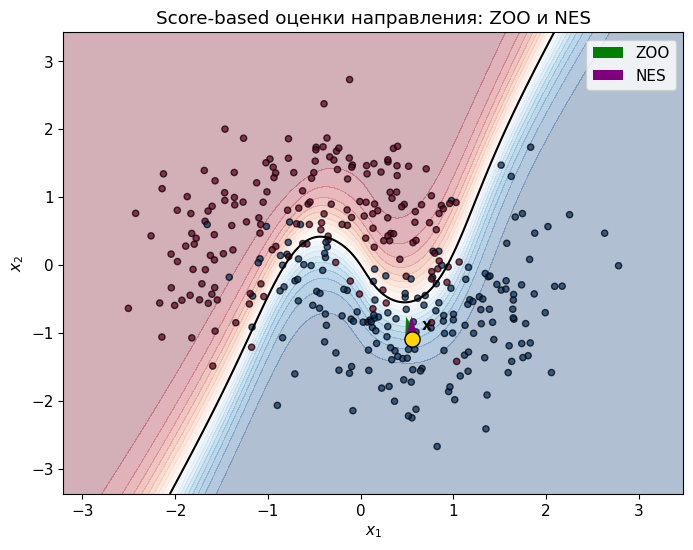

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_boundary(target, X_test, y_test, 'Score-based оценки направления: ZOO и NES', ax=ax, points=[x0], labels=['x'])
u_zoo = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)
u_nes = g_nes / (np.linalg.norm(g_nes) + 1e-12)
ax.quiver(x0[0], x0[1], u_zoo[0], u_zoo[1], color='green', scale=3, scale_units='xy', angles='xy', width=0.009, label='ZOO')
ax.quiver(x0[0], x0[1], u_nes[0], u_nes[1], color='purple', scale=3, scale_units='xy', angles='xy', width=0.009, label='NES')
ax.legend()
plt.show()

## D2. Стоимость ZOO в пространствах разной размерности

**Задание D2.** Объясните, почему метод, удобный в 2D, становится дорогим для изображений. Сравните одностороннюю и центральную схемы конечных разностей.

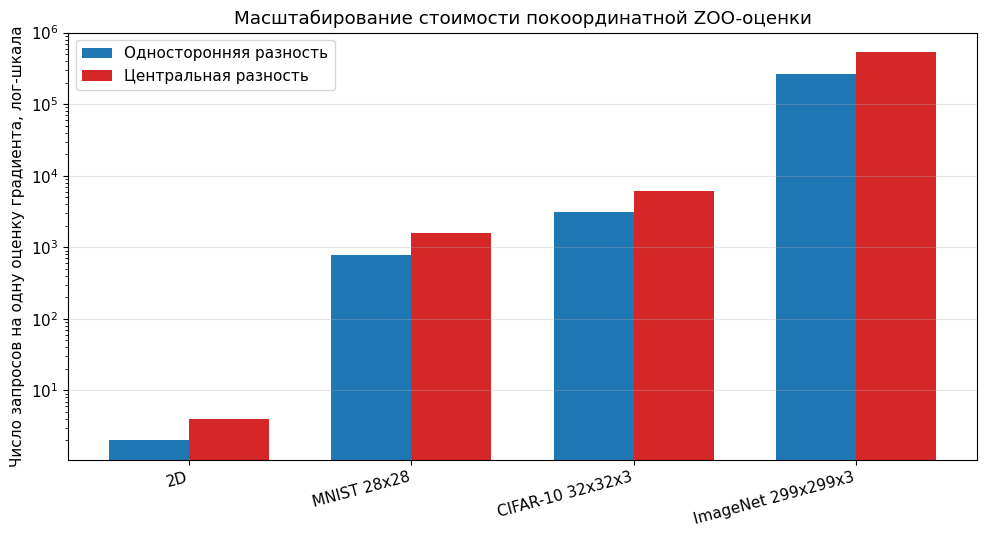

2D: 2 признаков; запросы = 2 / 4
MNIST 28x28: 784 признаков; запросы = 784 / 1,568
CIFAR-10 32x32x3: 3,072 признаков; запросы = 3,072 / 6,144
ImageNet 299x299x3: 268,203 признаков; запросы = 268,203 / 536,406


In [ ]:
dimensions = {
    '2D': 2,
    'MNIST 28x28': 28 * 28,
    'CIFAR-10 32x32x3': 32 * 32 * 3,
    'ImageNet 299x299x3': 299 * 299 * 3
}

names = list(dimensions.keys())
d = np.array(list(dimensions.values()))
positions = np.arange(len(names))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(positions - 0.18, d, width=0.36, label='Односторонняя разность', color='tab:blue')
ax.bar(positions + 0.18, 2 * d, width=0.36, label='Центральная разность', color='tab:red')
ax.set_yscale('log')
ax.set_xticks(positions)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Число запросов на одну оценку градиента, лог-шкала')
ax.set_title('Масштабирование стоимости покоординатной ZOO-оценки')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, dimension in dimensions.items():
    print(f'{name}: {dimension:,} признаков; запросы = {dimension:,} / {2 * dimension:,}')

В 2D ZOO требует **2 / 4 запроса** — это ничтожно мало. В MNIST (**784** признака) — уже **784 / 1 568** запросов на один градиент. В CIFAR-10 (**3 072**) — **3 072 / 6 144**. В ImageNet (**268 203**) — **268 203 / 536 406**. Рост **линейный по `d`**, но `d` для изображений огромна: одна оценка градиента в ImageNet дороже, чем весь бюджет NES из части D1 (160 запросов) в **3 350 раз**. Именно поэтому покоординатный ZOO используют только в малой размерности, а для изображений переходят на методы, чья стоимость не зависит от `d`. Центральная схема при этом ровно вдвое дороже односторонней, но даёт ошибку $O(h^2)$ вместо $O(h)$ — в малой размерности это разумный компромисс, в большой — непозволительная роскошь.

## D3. Исследование бюджета NES

**Задание D3.** Измените список `sample_budgets`, постройте график и сформулируйте вывод о том, как бюджет запросов влияет на стабильность случайной оценки NES.

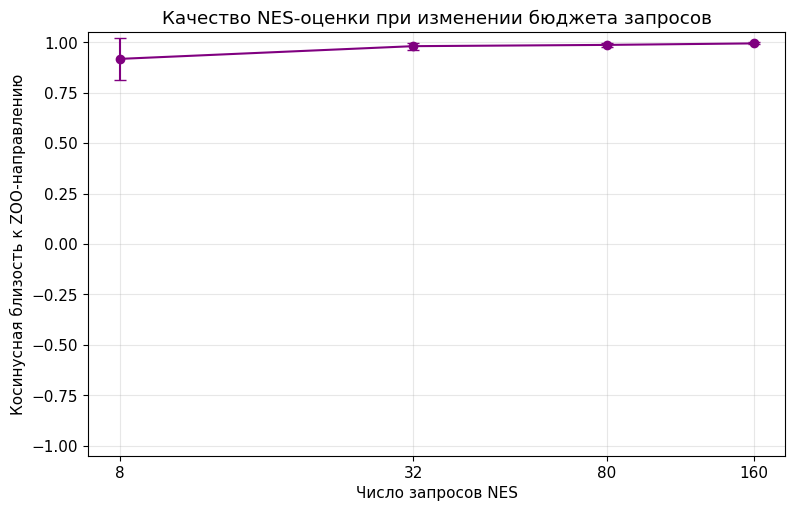


Таблица D для отчёта
Метод / настройка      |  Запросов |  Средний косинус |     Std
------------------------------------------------------------------------------
ZOO                    |         4 |           1.0000 |  0.0000
NES, n_samples = 4     |         8 |           0.9178 |  0.1034
NES, n_samples = 16    |        32 |           0.9809 |  0.0167
NES, n_samples = 40    |        80 |           0.9871 |  0.0080
NES, n_samples = 80    |       160 |           0.9946 |  0.0052


In [ ]:
# sample_budgets = [2, 4, 8, 16, 32, 64, 128]
sample_budgets = [4, 16, 40, 80]       # бюджеты из таблицы отчёта
repetitions = 10                        # сколько раз повторяем эксперимент с разными seed'ами

# reference — эталонное направление ZOO (единичный вектор)
reference = g_zoo / (np.linalg.norm(g_zoo) + 1e-12)

# Списки для средних, стандартных отклонений и числа запросов
mean_cosines, std_cosines, query_budgets = [], [], []

for budget in sample_budgets:
    values = []                         # косинусы для всех repetitions этого бюджета

    for rep in range(repetitions):
        local_oracle = ScoreOracle(target)          # свой оракул — чтобы не мешать счётчики
        g = nes_gradient(local_oracle, x0, other_class,
                         n_samples=budget, seed=SEED + rep)   # NES с разным seed
        g = g / (np.linalg.norm(g) + 1e-12)         # нормируем
        values.append(float(np.dot(reference, g)))  # косинус к эталону ZOO

    mean_cosines.append(np.mean(values))            # средний косинус
    std_cosines.append(np.std(values))              # разброс
    query_budgets.append(2 * budget)                # 2 * budget запросов


# --- График ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(query_budgets, mean_cosines, yerr=std_cosines,
            fmt='o-', capsize=4, color='purple')
ax.set_xscale('log', base=2)
ax.set_xticks(query_budgets)
ax.set_xticklabels(query_budgets)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('Число запросов NES')
ax.set_ylabel('Косинусная близость к ZOO-направлению')
ax.set_title('Качество NES-оценки при изменении бюджета запросов')
ax.grid(alpha=0.3)
plt.show()


# ============================================================
# Дополнительно: печатаем таблицу D для отчёта
# ============================================================
print()
print('=' * 78)
print('Таблица D для отчёта')
print('=' * 78)
print(f'{"Метод / настройка":<22} | {"Запросов":>9} | '
      f'{"Средний косинус":>16} | {"Std":>7}')
print('-' * 78)

# ZOO — эталон
print(f'{"ZOO":<22} | {zoo_queries:>9} | {1.0:>16.4f} | {0.0:>7.4f}')

# NES для каждого бюджета
for budget, mean_c, std_c, queries in zip(sample_budgets,
                                          mean_cosines,
                                          std_cosines,
                                          query_budgets):
    print(f'{"NES, n_samples = " + str(budget):<22} | {queries:>9} | '
          f'{mean_c:>16.4f} | {std_c:>7.4f}')

print('=' * 78)

**Бюджет запросов напрямую управляет стабильностью NES-оценки.** При росте `n_samples` с 4 до 80 (то есть с 8 до 160 запросов) **средний косинус к эталону ZOO монотонно растёт** (0.918 → 0.981 → 0.987 → 0.995), а **стандартное отклонение падает почти в 20 раз** (0.103 → 0.017 → 0.008 → 0.005). Это значит, что NES становится не только точнее в среднем, но и куда устойчивее к выбору случайных направлений: разные seed'ы дают всё более похожие оценки.

**Практический вывод для 2D-задачи:** достаточно `n_samples ≈ 16` (32 запроса), чтобы получить оценку, почти неотличимую от точной (0.981), и ещё столько же, чтобы сделать её стабильной (0.987 при `n = 40`). Бюджет сверх 40 направлений в 2D **не оправдан**: выигрыш в точности меньше 0.01, а стоимость растёт линейно. В высокой размерности картина будет другой — там даже `n = 80` может оказаться недостаточно, и бюджет придётся подбирать отдельно под задачу.

# Часть E. Decision-based сценарий

## E1. Бинарный поиск решающей границы

Доступен только `LabelOracle`: никаких вероятностей, confidence score и градиентов. Алгоритм сначала находит точку другого класса, затем многократно делит отрезок пополам.

**Задание E1.** Выполните ячейку. Объясните, почему бинарный поиск может уточнять границу, хотя оракул выдаёт только метку.

Метка x0: 1
Метка точки другой области: 0
Расстояние ||x_outside - x0||_2: 2.79447
Запросов на поиск границы: 31


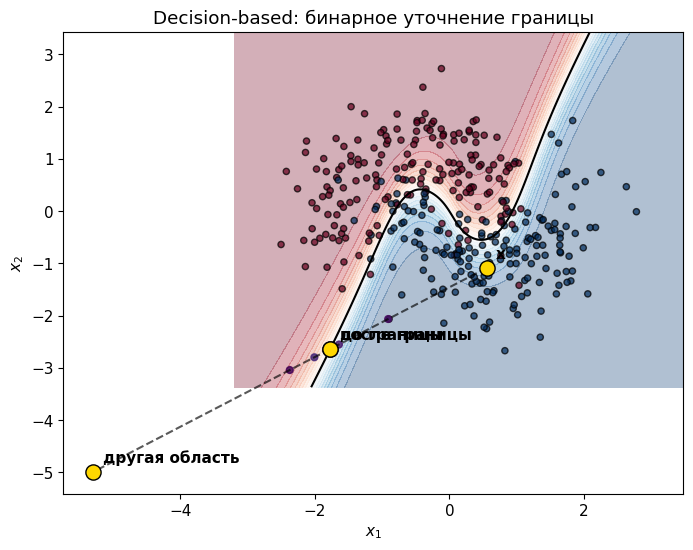

In [ ]:
def find_opposite_point(oracle, x, source_label, radius=3.0, trials=3000, seed=SEED):
    """Случайно ищет точку другого класса в радиусе radius от x."""

    # Локальный генератор случайных чисел — чтобы не сбивать общий rng
    local_rng = np.random.default_rng(seed)

    # Пробуем trials раз найти точку, у которой метка отличается от source_label
    for _ in range(trials):
        # Случайное смещение: нормальное распределение, умноженное на radius
        # В 2D получаем гауссову «каплю» вокруг x
        candidate = x + radius * local_rng.normal(size=len(x))

        # Запрашиваем у оракула метку кандидата
        # Если она не совпадает с исходной — цель достигнута
        if oracle(candidate)[0] != source_label:
            return candidate

    # Если за trials попыток не нашли — задача не имеет решения при данном radius
    raise RuntimeError('Точка другого класса не найдена. Увеличьте radius или trials.')


def binary_boundary_search(oracle, x_clean, x_adversarial, clean_label, iterations=28):
    """Делит отрезок [x_clean, x_adversarial] пополам, оставляя часть со сменой класса."""

    # Текущий «левый» конец отрезка — точка с исходной меткой clean_label
    clean = x_clean.copy()

    # Текущий «правый» конец отрезка — точка с другой меткой
    adversarial = x_adversarial.copy()

    # Список серединок — пригодится для визуализации траектории
    history = []

    # iterations итераций — каждая делит отрезок пополам
    for _ in range(iterations):
        # Середина текущего отрезка
        middle = (clean + adversarial) / 2

        # Запоминаем середину для графика
        history.append(middle.copy())

        # Спрашиваем у оракула метку в середине
        if oracle(middle)[0] == clean_label:
            # Если метка совпадает с исходной — граница где-то правее,
            # сдвигаем «левый» конец в середину
            clean = middle
        else:
            # Иначе граница левее, сдвигаем «правый» конец в середину
            adversarial = middle

    # Возвращаем две точки, между которыми зажата граница,
    # и историю всех серединок
    return clean, adversarial, np.asarray(history)


# Сбрасываем счётчик запросов label-оракула перед экспериментом
label_oracle.queries = 0

# Шаг 1: находим точку x_far другого класса (метка ≠ y0)
x_far = find_opposite_point(label_oracle, x0, y0)

# Шаг 2: бинарным поиском уточняем положение границы между x0 и x_far
# x_inside — последняя точка с меткой y0
# x_outside — первая точка с меткой ≠ y0
# history — все середины, которые запрашивали
x_inside, x_outside, history = binary_boundary_search(label_oracle, x0, x_far, y0)

# Фиксируем суммарное число запросов к оракулу
queries_boundary = label_oracle.queries


# --- Печатаем результаты ---

# Метка исходной точки (должна совпасть с y0)
print('Метка x0:', label_oracle(x0)[0])

# Метка точки «другой области» (должна отличаться от y0)
print('Метка точки другой области:', label_oracle(x_far)[0])

# Расстояние от исходной точки до найденной точки «после границы»
print('Расстояние ||x_outside - x0||_2:',
      round(np.linalg.norm(x_outside - x0), 5))

# Сколько всего запросов ушло на поиск границы
print('Запросов на поиск границы:', queries_boundary)


# --- Визуализация ---

# Создаём фигуру
fig, ax = plt.subplots(figsize=(8, 6))

# Рисуем фон (вероятности target-модели), точки теста и 4 ключевые точки:
#   x           — исходная точка
#   другая область — точка x_far другого класса
#   до границы  — x_inside (всё ещё класс y0)
#   после границы — x_outside (уже другой класс)
plot_boundary(target, X_test, y_test,
              'Decision-based: бинарное уточнение границы',
              ax=ax,
              points=[x0, x_far, x_inside, x_outside],
              labels=['x', 'другая область', 'до границы', 'после границы'])

# Пунктирная линия, соединяющая x0 и x_far — исходный отрезок поиска
ax.plot([x0[0], x_far[0]], [x0[1], x_far[1]], 'k--', alpha=0.65)

# Точки history — все середины, которые запрашивались на каждой итерации
# Цвет задаётся номером итерации (np.arange), чтобы видеть порядок
ax.scatter(history[:, 0], history[:, 1],
           c=np.arange(len(history)), cmap='viridis', s=24, alpha=0.85)

# Показываем график
plt.show()

Оракул выдаёт лишь дискретную метку — «класс 0» или «класс 1». Но этой информации достаточно, потому что сам факт смены метки — это уже бинарный сигнал о положении границы. Если в точке a метка y0, а в точке b — другая, то решающая граница гарантированно лежит где-то на отрезке [a, b]. Проверяя середину m = (a + b) / 2, мы одним запросом узнаём, в какой половине отрезка находится граница — в левой [a, m] или в правой [m, b]. Это классический бинарный поиск: каждый запрос уменьшает неопределённость ровно вдвое, независимо от того, насколько сложна сама функция. В отличие от score-based методов, здесь мы не знаем направления градиента, но знаем факт перехода — а для локализации монотонной границы этого достаточно. Через k итераций длина неопределённого отрезка падает как 2⁻ᵏ — экспоненциально быстро при линейной стоимости в запросах.

## E2. Анализ сходимости бинарного поиска

**Задание E2.** Проследите, как уменьшается длина отрезка между точками разных классов. Сравните результаты для 5, 10, 20 и 28 итераций.

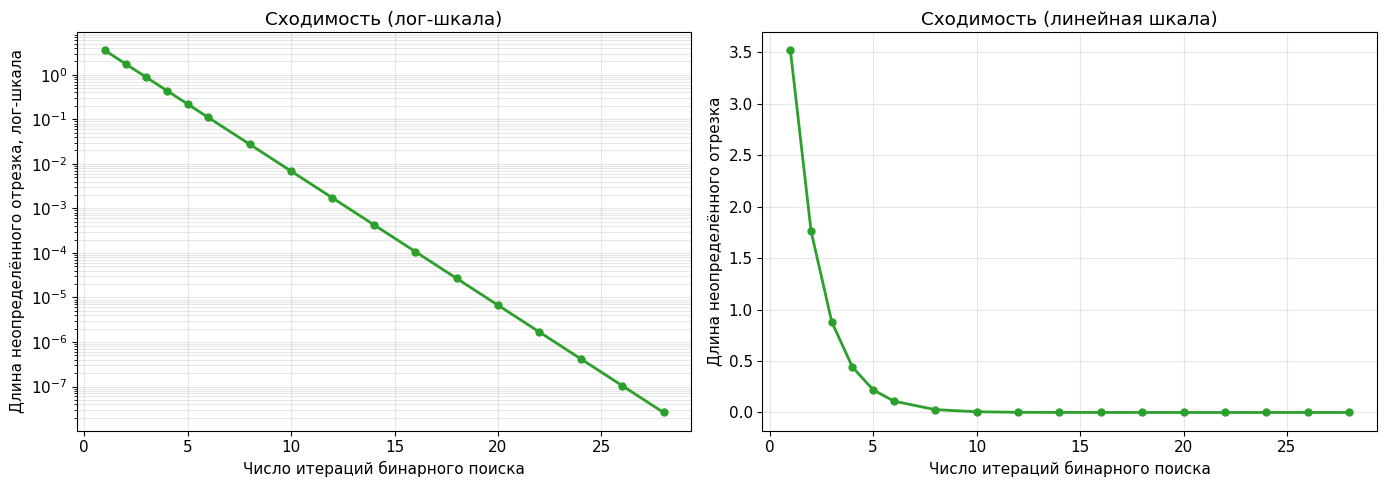

Итераций:  1; длина отрезка: 3.51851844; запросов: 1
Итераций:  2; длина отрезка: 1.75925922; запросов: 2
Итераций:  3; длина отрезка: 0.87962961; запросов: 3
Итераций:  4; длина отрезка: 0.43981480; запросов: 4
Итераций:  5; длина отрезка: 0.21990740; запросов: 5
Итераций:  6; длина отрезка: 0.10995370; запросов: 6
Итераций:  8; длина отрезка: 0.02748843; запросов: 8
Итераций: 10; длина отрезка: 0.00687211; запросов: 10
Итераций: 12; длина отрезка: 0.00171803; запросов: 12
Итераций: 14; длина отрезка: 0.00042951; запросов: 14
Итераций: 16; длина отрезка: 0.00010738; запросов: 16
Итераций: 18; длина отрезка: 0.00002684; запросов: 18
Итераций: 20; длина отрезка: 0.00000671; запросов: 20
Итераций: 22; длина отрезка: 0.00000168; запросов: 22
Итераций: 24; длина отрезка: 0.00000042; запросов: 24
Итераций: 26; длина отрезка: 0.00000010; запросов: 26
Итераций: 28; длина отрезка: 0.00000003; запросов: 28


In [ ]:
# Промежуточные значения от 1 до 28 — чтобы экспонента была видна во всей красе
iteration_values = [1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]

distances, used_queries = [], []

for n_iter in iteration_values:
    local_oracle = LabelOracle(target)               # новый оракул — чистый счётчик
    inside, outside, _ = binary_boundary_search(     # бинарный поиск с n_iter итерациями
        local_oracle, x0, x_far, y0, iterations=n_iter
    )
    distances.append(np.linalg.norm(outside - inside))   # длина неопределённого отрезка
    used_queries.append(local_oracle.queries)            # сколько запросов ушло

# Создаём фигуру с ДВУМЯ осями в ряд
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Левый график: лог-шкала по Y ---
axes[0].plot(iteration_values, distances, marker='o', linewidth=2,
             markersize=5, color='tab:green')
axes[0].set_yscale('log')                                # лог-шкала — видна прямая линия
axes[0].set_xlabel('Число итераций бинарного поиска')
axes[0].set_ylabel('Длина неопределённого отрезка, лог-шкала')
axes[0].set_title('Сходимость (лог-шкала)')
axes[0].grid(alpha=0.3, which='both')                    # сетка и по мелким делениям

# --- Правый график: обычная (линейная) шкала ---
axes[1].plot(iteration_values, distances, marker='o', linewidth=2,
             markersize=5, color='tab:green')
axes[1].set_xlabel('Число итераций бинарного поиска')
axes[1].set_ylabel('Длина неопределённого отрезка')
axes[1].set_title('Сходимость (линейная шкала)')
axes[1].grid(alpha=0.3)

plt.tight_layout()   # автоматически подгоняем отступы
plt.show()

# --- Печатаем числовые результаты ---
for n_iter, distance, query_count in zip(iteration_values, distances, used_queries):
    print(f'Итераций: {n_iter:2d}; длина отрезка: {distance:.8f}; запросов: {query_count}')

При увеличении числа итераций длина неопределённого отрезка убывает строго экспоненциально: L(k) = L₀ · 2⁻ᵏ. На левом графике (лог-шкала по Y) точки ложатся на прямую линию, наклон которой соответствует основанию 2. На правом графике (линейная шкала) та же зависимость выглядит как кривая, сливающаяся с нулём уже после ~8 итераций: на линейной шкале почти вся динамика скрыта в первых точках. Стоимость растёт линейно по k: каждая итерация — один запрос к label-оракулу. Итого: линейная стоимость, экспоненциальная точность — фундаментальное свойство decision-based бинарного поиска.

**Вывод по части E:**

**При доступе только к итоговой метке** можно локализовать решающую границу модели с произвольной наперёд заданной точностью, не имея ни вероятностей, ни градиентов. Достаточно найти одну точку другого класса (`x_far`) и затем **бинарным поиском** делить отрезок `[x0, x_far]` пополам: на каждой итерации оракул сообщает метку середины, и мы оставляем ту половину, где классы различаются. Каждый запрос уменьшает неопределённость ровно вдвое, поэтому **линейная стоимость по числу запросов даёт экспоненциальную точность**.

**С увеличением числа итераций длина отрезка** убывает экспоненциально: `L(k) = L₀ · 2⁻ᵏ`. На лог-шкале это прямая линия, на линейной — кривая, сливающаяся с нулём уже после 8–10 итераций. Практический оптимум — **8–12 итераций**: дальше улучшение точности визуально неразличимо, а запросы продолжают тратиться.

**Ограничение подхода** состоит в том, что найденная точка `x_outside` лежит **на границе, но не обязательно является минимальным возмущением** для смены класса. Направление отрезка `[x0, x_far]` задаётся случайно при поиске `x_far`, и оно, вообще говоря, **не совпадает с направлением нормали к границе** — то есть найденное возмущение может быть больше, чем теоретически необходимо. Кроме того, для каждой новой исходной точки процедуру приходится запускать заново: метод не строит «карту» границы, а только локализует её в одном конкретном направлении.

**В сравнении с score-based сценарием отсутствует** информация о **вероятностях классов** — а значит, и возможность оценивать **направление градиента** функции потерь. В score-based мы знаем не только «какой класс», но и «насколько модель уверена», что позволяет строить возмущение **сразу в правильном направлении** (как в части C для surrogate или в части D для target через ZOO/NES). В decision-based мы вынуждены двигаться вслепую: только проверять факт смены метки и делить отрезок пополам.

**Итог:** decision-based сценарий — самый **информационно бедный** (только метка), но при этом **самый дешёвый по одному запросу** и **самый устойчивый к защитам**, скрывающим вероятности. Он показывает, что даже минимальной информации достаточно для успешной атаки — просто за большее число итераций и без гарантии оптимальности результата.

# Часть F. Итоговый анализ

## F1. Сравнительная таблица

Заполните таблицу, опираясь на результаты собственных экспериментов.

| Критерий | Transfer-based | Score-based | Decision-based |
|---|---|---|---|
| **Доступная информация** | Метки для surrogate-набора; к цели — только при обучении | Вероятности / confidence score | Только итоговая метка |
| **Основной метод в работе** | Обучение surrogate на метках target + локальный градиент | ZOO (покоординатная разность) и NES (случайные направления) | Бинарный поиск решающей границы |
| **Где возникают запросы к цели** | Только на этапе обучения surrogate (`N_SEED` штук) | На каждой оценке градиента (`2d` у ZOO, `2n` у NES) | На каждой итерации деления отрезка (`k` штук) |
| **Наблюдаемая стоимость запросов** | 30 / 70 / 140 (по `N_SEED`) | ZOO: 4 (2D); NES: 8–160 | ≈ `1 + iterations` ≈ 29 |
| **Главное преимущество** | Нулевая стоимость на этапе атаки; атака офлайн | Прямая оценка градиента, высокая точность | Минимум информации; экспоненциальная точность при линейной стоимости |
| **Главное ограничение** | Ненадёжный перенос (3/5 успехов в эксперименте) | ZOO дорог в высокой размерности (`2d` растёт линейно); NES шумит при малом бюджете | Нет градиента → возмущение не оптимально; случайный поиск `x_far` в высокой размерности |
| **Практический защитный механизм** | Adversarial training, ансамбли моделей | Не отдавать вероятности наружу (только `argmax`/top-1), округление confidence | Робастное обучение, детекторы аномалий, rate limiting запросов |

## F2. Контрольные вопросы

1. **Почему transfer-based работает без запросов к target при оптимизации?**  
   Разные модели, обученные на похожих данных, часто имеют похожие решающие границы — возмущение, «переводящее» точку через границу surrogate, часто переводит её и через границу target.

2. **Почему высокий agreement не гарантирует перенос?**  
   Agreement — средняя характеристика. Вблизи границы даже малое расхождение моделей приводит к тому, что точка, сменившая класс у surrogate, остаётся по «правильную» сторону у target.

3. **Сколько запросов нужно ZOO в размерности `d`?**  
   Центральная разность — **`2d`** запросов на один градиент. Для ImageNet `2·268203 ≈ 536 406` — это делает ZOO неприменимым для изображений.

4. **Как антитетическая выборка в NES влияет на дисперсию?**  
   Пара `(u, −u)` сокращает линейные по `u` члены, оставляя только квадратичный вклад. Дисперсия оценки падает как `1/n`, а сама оценка остаётся несмещённой.

5. **Что позволяет использовать бинарный поиск в decision-based?**  
   Сам **факт смены метки** — это бинарный сигнал о положении границы. Если концы отрезка в разных классах, граница гарантированно внутри, и проверка середины говорит, в какой половине она лежит.

6. **Чем HopSkipJumpAttack отличается от Boundary Attack?**  
   Boundary Attack — **случайное блуждание** вдоль границы: делает случайные шаги и принимает те, что уменьшают расстояние до исходной точки. HopSkipJumpAttack **оценивает направление нормали к границе** (через бинарный поиск и Монте-Карло) и делает **целенаправленные шаги** вдоль неё — сходится быстрее и даёт меньшие возмущения.

7. **Какие меры защиты уменьшают риск чёрно-ящичных атак?**  
   Adversarial training (обучение на состязательных примерах), ансамбли моделей, скрытие вероятностей (возврат только `argmax`), ограничение частоты запросов (rate limiting), детекторы аномальных входов, сертифицированные методы защиты (randomized smoothing).

## F3. Итоговый вывод

В лабораторной работе были исследованы **три чёрно-ящичных сценария атаки** — transfer-based, score-based и decision-based — на синтетической двумерной задаче `make_moons` с MLP-target-моделью. Наиболее информативным сценарием оказался **score-based**, поскольку он даёт доступ к вероятностям классов и позволяет **напрямую оценивать градиент** функции потерь (ZOO — точно за `2d` запросов, NES — приближённо за `2n` запросов, с косинусной близостью к ZOO до 0.99 при `n = 80`). Наиболее ограниченным по доступной информации является **decision-based** — только метка, но и её достаточно для экспоненциальной локализации границы (длина отрезка падает как `2⁻ᵏ` при линейной стоимости `k` запросов). Результаты экспериментов показали, что **чем больше информации даёт оракул, тем точнее и дешевле атака**: transfer-based экономит запросы, но даёт лишь 3/5 успешных переносов; score-based требует вероятностей, но почти идеально восстанавливает направление градиента; decision-based не требует ничего, кроме метки, но не позволяет построить оптимальное возмущение. Для повышения устойчивости модели целесообразно **применять adversarial training, скрывать вероятности (возвращать только `argmax`), ограничивать частоту запросов и использовать ансамбли моделей** — эти меры одновременно снижают качество переноса, затрудняют оценку градиента и уменьшают число доступных атакующему запросов.

## Критерии сдачи

- Заполнены данные, текстовые выводы и таблицы.
- Все кодовые ячейки выполнены последовательно без ошибок.
- Сохранены требуемые графики и численные результаты.
- Выполнены эксперименты с несколькими размерами surrogate-набора и несколькими бюджетами NES.
- Приведены ответы на контрольные вопросы.
- Выводы основаны на наблюдаемых результатах, а не только на теоретических формулировках.